In [1]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
import folium
from shapely.geometry import box, Point, Polygon
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt
import yaml
from dotenv import load_dotenv

In [2]:
# get path to project root directory
project_root = Path.cwd().parents[0]

# build path to yaml config file
config_path = project_root / "configs"/"paths.yaml"

In [3]:
# load yaml file into python dictionary
with open(config_path) as f:
    paths = yaml.safe_load(f)

paths

{'data': {'external': 'data/external',
  'raw': 'data/raw',
  'processed': 'data/processed',
  'results': 'results',
  'imagery': 'data/imagery'},
 'outputs': {'dynamic_maps': 'outputs/maps/dynamic',
  'static_maps': 'output/maps/static',
  'figures': 'output/figures',
  'tables': 'outputs/tables'},
 'imagery': {'nakivale_sample': 'data/imagery/nakivale_sample'}}

In [4]:
# build data directory using paths from yaml config
data_dir = project_root/paths['data']['processed']

# build path to external data using paths from yaml config
data_external = project_root/paths['data']['external']

# finally build path to our deduped settlements geojson file
settlements_path = data_dir / "UNHCR_poc_boundaries-Uganda_attributed_deduped.geojson"

# build path to our regions geojson file
refugee_regions_path = data_external / "refugeehosting_regions.geojson"

In [5]:
# build path to output directory for processed hexbin data
output_dir = project_root/paths['data']['processed']

# build path to output directory for maps
maps_dir = project_root/paths['outputs']['dynamic_maps']

In [6]:
# load settlements into a gdf
settlements = gpd.read_file(settlements_path)
settlements.head(1)

,id,name,objectid,pcode,iso3,name_2,name_alt,loc_type,loc_subtype,createdate,...,source,unhcr_assist,footnote,comments,status,globalid,lat,lon,date_str,geometry
0,0,Palabek,27594.0,UGAs032271,UGA,Palabek RC,None,37.0,None,1.541376e+12,...,UNHCR,1.0,None,None,1.0,{9611730D-6DCD-4DBC-BF0F-C4156A5FA034},3.36355,32.41501,2018-11-04,"POLYGON ((451961.635 371230.291, 451957.294 37..."


In [7]:
# load regions into a gdf
refugee_regions = gpd.read_file(refugee_regions_path)
refugee_regions = gpd.GeoDataFrame(refugee_regions[['ADM2_EN','ADM1_EN', 'ADM0_EN','geometry']], geometry = 'geometry').to_crs(32636)
refugee_regions.head(1)

,ADM2_EN,ADM1_EN,ADM0_EN,geometry
0,Adjumani,Northern,Uganda,"MULTIPOLYGON (((394041.762 396748.274, 394020...."


C:\Users\Zachary\AppData\Local\Temp\ipykernel_53500\1322128136.py:51: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower right")


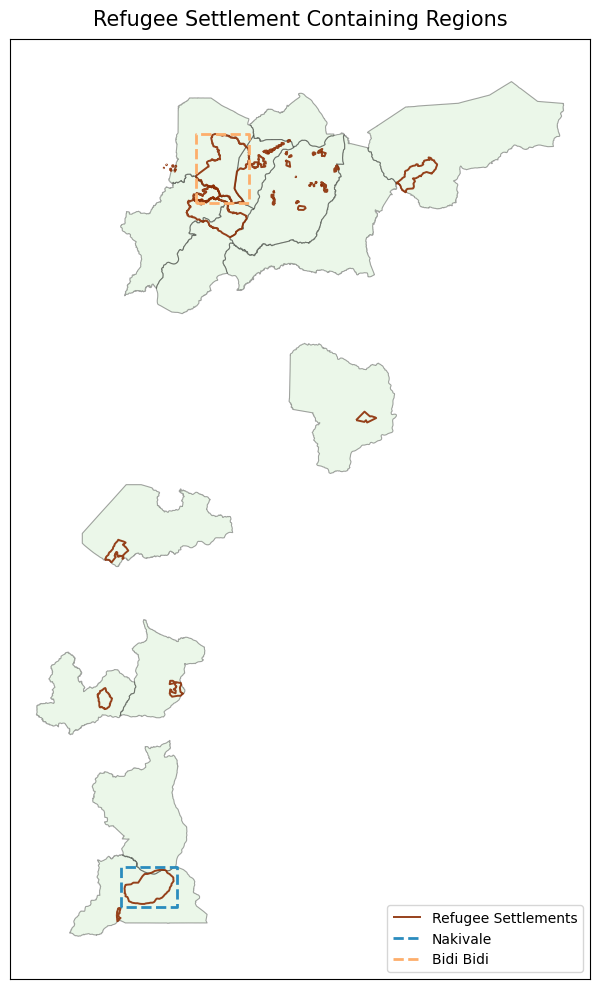

In [8]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box

# --- Filter settlements ---
nakivale = settlements[settlements["name"].str.contains("nakiv", case=False, na=False)]
bidi_bidi = settlements[settlements["name"].str.contains("bidi", case=False, na=False)]

# --- Compute bounding boxes ---
nak_minx, nak_miny, nak_maxx, nak_maxy = nakivale.buffer(2000).total_bounds
bidi_minx, bidi_miny, bidi_maxx, bidi_maxy = bidi_bidi.buffer(000).total_bounds

nak_box = gpd.GeoDataFrame(geometry=[box(nak_minx, nak_miny, nak_maxx, nak_maxy)], crs=settlements.crs)
bidi_box = gpd.GeoDataFrame(geometry=[box(bidi_minx, bidi_miny, bidi_maxx, bidi_maxy)], crs=settlements.crs)

# --- Plot main map ---
fig, ax = plt.subplots(figsize=(8, 10))

# Soft sage green (ColorBrewer Greens)
refugee_regions.plot(
    ax=ax, color="#c7e9c0", edgecolor="black",
    alpha=0.35, linewidth=0.8, label="Refugee Regions"
)

# Deep brown-red (ColorBrewer OrRd)
settlements.boundary.plot(
    ax=ax, edgecolor="#8c2d04", alpha=0.9,
    linewidth=1.4, label="Refugee Settlements"
)

# --- Bounding boxes ---
# Teal (ColorBrewer Blues)
nak_box.boundary.plot(
    ax=ax, edgecolor="#2b8cbe", linewidth=2,
    linestyle="--", label="Nakivale"
)

# Warm gold (ColorBrewer Oranges)
bidi_box.boundary.plot(
    ax=ax, edgecolor="#fdae6b", linewidth=2,
    linestyle="--", label="Bidi Bidi"
)

# --- Labels and style ---
ax.set_title("Refugee Settlement Containing Regions", fontsize=15, pad=10)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])

ax.legend(loc="lower right")

plt.tight_layout()
plt.show()



In [9]:
from math import sqrt
from shapely.geometry import box, Point
import numpy as np
import geopandas as gpd

def make_grid_mesh_over_union(polys_gdf, cell_area, origin=None):
    """
    Build a square grid covering the union of all polygons,
    then return all cells whose centroids lie within the union (no clipping).

    Parameters
    ----------
    polys_gdf : GeoDataFrame
        Input polygons. Must be in a projected CRS in meters.
    cell_area : float
        Target area of each grid cell in square meters.
    origin : (float, float) or None
        Optional (x0, y0) for grid origin. If None, derived from bounds.

    Returns
    -------
    GeoDataFrame
        Square grid cells (polygons) covering the union.
    """
    # sanity check: projected CRS
    if polys_gdf.crs is None or polys_gdf.crs.is_geographic:
        raise ValueError("Polygons must be in a projected CRS in meters (e.g., EPSG:32636).")

    # side length for square with desired area
    side = sqrt(cell_area)
    width = side
    height = side

    # small buffer to make sure we cover edges
    polys_gdf = polys_gdf.buffer(10000) # previous was (side) made it 10km 
    minx, miny, maxx, maxy = polys_gdf.total_bounds

    # origin
    if origin is None:
        x0, y0 = minx - width, miny - height
    else:
        x0, y0 = origin

    cols = np.arange(x0, maxx + width, width)
    rows = np.arange(y0, maxy + height, height)

    union = polys_gdf.unary_union

    cells = []
    for x in cols:
        for y in rows:
            # centroid of the cell
            cx = x + width / 2
            cy = y + height / 2
            c = Point(cx, cy)

            # only keep cells whose centroids fall inside union
            if union.contains(c):
                cells.append(box(x, y, x + width, y + height))

    return gpd.GeoDataFrame(geometry=cells, crs=polys_gdf.crs)


In [10]:
areas = [250000, 62500, 15625]  # in square meters
grid_250k = make_grid_mesh_over_union(refugee_regions, areas[0])
grid_62k  = make_grid_mesh_over_union(refugee_regions, areas[1])
grid_15k  = make_grid_mesh_over_union(refugee_regions, areas[2])

C:\Users\Zachary\AppData\Local\Temp\ipykernel_53500\2493051252.py:47: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  union = polys_gdf.unary_union
C:\Users\Zachary\AppData\Local\Temp\ipykernel_53500\2493051252.py:47: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  union = polys_gdf.unary_union
C:\Users\Zachary\AppData\Local\Temp\ipykernel_53500\2493051252.py:47: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  union = polys_gdf.unary_union


C:\Users\Zachary\AppData\Local\Temp\ipykernel_53500\2836550107.py:21: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


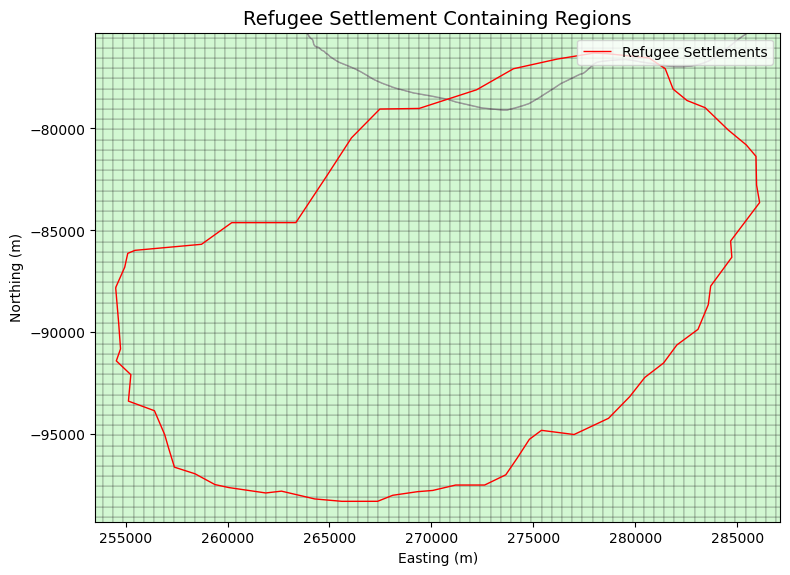

In [11]:
# plot nakivale and its bounding box
fig, ax = plt.subplots(figsize=(8, 10))

# plot the Nakivale polygon(s)
refugee_regions.plot(ax=ax, color='lightgreen', edgecolor = 'black',linewidth=1, label='Refugee Regions')

# Plot the bounding box outline
nakivale = settlements[settlements['name'].str.lower()=='nakivale']
nakivale.boundary.plot(ax=ax, edgecolor='red', linewidth=1, label='Refugee Settlements')

# Plot the hexgrid
grid_250k.plot(ax = ax, color = 'white', edgecolor = 'black', alpha = 0.6, linewidth = 0.25, label = 'hexgrid' )

# Add labels and styling
minx, miny, maxx, maxy = nakivale.buffer(1000).total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title("Refugee Settlement Containing Regions", fontsize=14)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend()

plt.tight_layout()
plt.show()

In [12]:

# plot the Nakivale polygon(s)
refugee_regions.plot(ax=ax, color='lightgreen', edgecolor = 'black',linewidth=1, label='Refugee Regions')

# Plot the bounding box outline
# nakivale = settlements[settlements['name'].str.lower()=='nakivale']
# nakivale.boundary.plot(ax=ax, edgecolor='red', linewidth=1, label='Refugee Settlements')
settlements.boundary.plot(ax=ax, edgecolor='red', linewidth=1, label='Refugee Settlements')

# Plot the hexgrid
grid_250k.plot(ax = ax, color = 'white', edgecolor = 'black', alpha = 0.5, linewidth = 0.25, label = 'hexgrid' )

# Add labels and styling
# minx, miny, maxx, maxy = nakivale.buffer(1000).total_bounds
# ax.set_xlim(minx, maxx)
# ax.set_ylim(miny, maxy)
ax.set_title("Refugee Settlement Containing Regions", fontsize=14)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend()

plt.tight_layout()
plt.show()

C:\Users\Zachary\AppData\Local\Temp\ipykernel_53500\3776877375.py:19: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


<Figure size 640x480 with 0 Axes>

In [13]:
def process_mesh(grid_gdf, refugee_regions, settlements, out_path):

    # Assign regions by centroid containment
    cell_centroids = grid_gdf.copy()
    cell_centroids["geometry"] = cell_centroids.geometry.centroid

    cell_with_region = (
        gpd.sjoin(
            cell_centroids.assign(OID=np.arange(len(cell_centroids))),
            refugee_regions,
            how="left",
            predicate="within"
        )
        .merge(grid_gdf.assign(OID=np.arange(len(grid_gdf))), on="OID", suffixes=("_pt", ""))
        .drop(columns=["index_right"])
    )

    # Assign settlements by intersection
    grid_with_settlements = (
        gpd.sjoin(
            cell_with_region.assign(OID=np.arange(len(cell_with_region))),
            settlements[['name', 'geometry']],
            how='left',
            predicate='intersects'
        )
        .drop(columns=['geometry_pt', 'index_right'])
    )

    # Reproject, compute centroids, and add lat/lon
    grid_with_settlements = grid_with_settlements.to_crs(4326)
    grid_with_settlements['lat'] = grid_with_settlements.centroid.y
    grid_with_settlements['lon'] = grid_with_settlements.centroid.x
    grid_with_settlements = grid_with_settlements.to_crs(32636)

    # Rename 'name' column
    grid_with_settlements = grid_with_settlements.rename(columns={'name': 'settlement_name'})

    # Reorder columns (geometry last)
    cols = list(grid_with_settlements.columns)
    cols_reordered = [c for c in cols if c != 'geometry'] + ['geometry']
    grid_with_settlements = grid_with_settlements[cols_reordered]

    # Save to GeoJSON
    grid_with_settlements.to_file(out_path, driver="GeoJSON")
    print(f"Saved: {out_path}")

    return grid_with_settlements

In [14]:
# For grids instead of hexes
grid_meshes = {
    "250k": grid_250k,
    "62k": grid_62k,
    "15k": grid_15k
}

for label, grid_gdf in grid_meshes.items():
    out_file = f"uganda_grids_{label}_lcluc_10k_buffer_v1.geojson"
    out_path = output_dir / out_file
    process_mesh(grid_gdf, refugee_regions, settlements, out_path)

C:\Users\Zachary\AppData\Local\Temp\ipykernel_53500\4026161810.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid_with_settlements['lat'] = grid_with_settlements.centroid.y
C:\Users\Zachary\AppData\Local\Temp\ipykernel_53500\4026161810.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid_with_settlements['lon'] = grid_with_settlements.centroid.x


Saved: c:\Users\Zachary\phd_classes\uganda\data\processed\uganda_grids_250k_lcluc_10k_buffer_v1.geojson


C:\Users\Zachary\AppData\Local\Temp\ipykernel_53500\4026161810.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid_with_settlements['lat'] = grid_with_settlements.centroid.y
C:\Users\Zachary\AppData\Local\Temp\ipykernel_53500\4026161810.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid_with_settlements['lon'] = grid_with_settlements.centroid.x


Saved: c:\Users\Zachary\phd_classes\uganda\data\processed\uganda_grids_62k_lcluc_10k_buffer_v1.geojson


C:\Users\Zachary\AppData\Local\Temp\ipykernel_53500\4026161810.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid_with_settlements['lat'] = grid_with_settlements.centroid.y
C:\Users\Zachary\AppData\Local\Temp\ipykernel_53500\4026161810.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid_with_settlements['lon'] = grid_with_settlements.centroid.x


Saved: c:\Users\Zachary\phd_classes\uganda\data\processed\uganda_grids_15k_lcluc_10k_buffer_v1.geojson
